# 05 — Tuning de RF + XGBoost

**Objetivo**: cerrar el gap de F1-macro que dejó el notebook 04 (RF default
sacó 0.64 en val full vs 0.95 en val balanced). Tuneamos los dos modelos
de tree ensembles más usados en producción para que la comparación sea
apples-to-apples.

**Estrategia**:

1. **Tuning del RF** con grid de 16 configs.
2. **Tuning de XGBoost** con grid de 16 configs.
3. **Comparación final** de 4 modelos: RF default, RF tuned, XGBoost
   default, XGBoost tuned.
4. La decisión de qué modelo va al notebook 06 (entrenamiento final +
   export de joblibs) sale de esta comparación.

**Inputs**: `datasets/processed/cicids_split.parquet` (output de nb04).

In [1]:
import os
import sys
import time
import contextlib
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='muted')

PROCESSED_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'datasets', 'processed'))
SPLIT_PATH = os.path.join(PROCESSED_DIR, 'cicids_split.parquet')

if not os.path.isfile(SPLIT_PATH):
    raise FileNotFoundError(
        f"No existe {SPLIT_PATH}.\n"
        "Generalo corriendo notebooks 02 y 04 primero."
    )

@contextlib.contextmanager
def silence_native_stderr():
    """Suprime stderr a nivel OS (silencia el 'nvidia-smi: command not found'
    que XGBoost imprime al detectar hardware en máquinas sin GPU)."""
    saved = os.dup(2)
    null = os.open(os.devnull, os.O_WRONLY)
    os.dup2(null, 2)
    try:
        yield
    finally:
        os.dup2(saved, 2)
        os.close(null)
        os.close(saved)

SEED = 42

## 1. Carga del split y preparación

Reusamos el split exacto del notebook 04 — eso garantiza que cualquier
mejora de F1 acá venga del modelo y no de un train/val/test distinto.

In [2]:
df = pd.read_parquet(SPLIT_PATH)
features = [c for c in df.columns if c not in ('Day', 'Label_6', 'split')]
print(f"Features: {len(features)}")
print(f"Splits: {df['split'].value_counts().to_dict()}")

Features: 47
Splits: {'train': 1619667, 'test': 347072, 'val': 347071}


In [3]:
# Sample del train: 5K por clase (mismo que nb04)
N_PER_CLASS = 5000
train_full = df[df['split'] == 'train']
train_parts = []
for cat, grp in train_full.groupby('Label_6'):
    train_parts.append(grp.sample(n=min(N_PER_CLASS, len(grp)), random_state=SEED))
train_sample = pd.concat(train_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

X_train = train_sample[features].values
y_train_str = train_sample['Label_6'].values

val = df[df['split'] == 'val']
X_val = val[features].values
y_val_str = val['Label_6'].values

# LabelEncoder para que los ints sean compatibles con XGBoost
le = LabelEncoder()
y_train = le.fit_transform(y_train_str)
y_val = le.transform(y_val_str)
classes = list(le.classes_)
print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Clases: {classes}")

Train: (23900, 47) | Val: (347071, 47)
Clases: ['Benign', 'Brute Force', 'DDoS', 'DoS', 'Reconnaissance', 'Web Attack']


## 2. Tuning del Random Forest

**Grid de 16 configs**. Validación holdout (no CV) sobre val — ya tenemos
val/test del split, CV multiplicaría el tiempo sin agregar señal.

| Hyperparameter | Valores | Por qué |
|---|---|---|
| `n_estimators` | 200, 500 | Más árboles → menos varianza en minorías |
| `max_depth` | None, 30 | None = puras (overfit posible). 30 = trade-off |
| `min_samples_leaf` | 1, 5 | 1 permite hojas con un solo flujo. 5 generaliza mejor |
| `class_weight` | balanced, balanced_subsample | Subsample recalcula pesos por bootstrap, mejor para imbalance |

In [4]:
rf_grid = {
    'n_estimators':     [200, 500],
    'max_depth':        [None, 30],
    'min_samples_leaf': [1, 5],
    'class_weight':     ['balanced', 'balanced_subsample'],
}

results_rf = []
combos = list(itertools.product(*rf_grid.values()))
print(f"Probando {len(combos)} configuraciones de RF...\n")

for i, combo in enumerate(combos, 1):
    params = dict(zip(rf_grid.keys(), combo))
    t0 = time.time()
    clf = RandomForestClassifier(n_jobs=-1, random_state=SEED, **params)
    clf.fit(X_train, y_train)
    t_train = time.time() - t0
    y_pred = clf.predict(X_val)
    f1m = f1_score(y_val, y_pred, average='macro')
    results_rf.append({**params, 'F1_macro': round(f1m, 4), 'train_s': round(t_train, 1)})
    print(f"  [{i:>2}/{len(combos)}] n_est={params['n_estimators']:>3} "
          f"depth={str(params['max_depth']):>4} leaf={params['min_samples_leaf']} "
          f"cw={params['class_weight'][:13]:<13} → F1={f1m:.4f} ({t_train:.0f}s)")

results_rf_df = pd.DataFrame(results_rf).sort_values('F1_macro', ascending=False)
print(f"\nTop 5 RF:")
results_rf_df.head(5)

Probando 16 configuraciones de RF...



  [ 1/16] n_est=200 depth=None leaf=1 cw=balanced      → F1=0.6366 (0s)


  [ 2/16] n_est=200 depth=None leaf=1 cw=balanced_subs → F1=0.6376 (1s)


  [ 3/16] n_est=200 depth=None leaf=5 cw=balanced      → F1=0.6676 (0s)


  [ 4/16] n_est=200 depth=None leaf=5 cw=balanced_subs → F1=0.6698 (1s)


...

  [13/16] n_est=500 depth=  30 leaf=1 cw=balanced      → F1=0.6366 (1s)


  [14/16] n_est=500 depth=  30 leaf=1 cw=balanced_subs → F1=0.6350 (2s)


  [15/16] n_est=500 depth=  30 leaf=5 cw=balanced      → F1=0.6678 (1s)


  [16/16] n_est=500 depth=  30 leaf=5 cw=balanced_subs → F1=0.6690 (2s)

Top 5 RF:


,n_estimators,max_depth,min_samples_leaf,class_weight,F1_macro,train_s
3,200,NaN,5,balanced_subsample,0.6698,0.7
7,200,30.0,5,balanced_subsample,0.6698,0.9
15,500,30.0,5,balanced_subsample,0.6690,2.2
11,500,NaN,5,balanced_subsample,0.6690,2.1
10,500,NaN,5,balanced,0.6678,1.4


In [5]:
# Mejor RF — guardamos params y reentrenamos
best = results_rf_df.iloc[0]
best_params_rf = {k: best[k] for k in rf_grid.keys()}
if pd.isna(best_params_rf['max_depth']):
    best_params_rf['max_depth'] = None
else:
    best_params_rf['max_depth'] = int(best_params_rf['max_depth'])
best_params_rf['n_estimators'] = int(best_params_rf['n_estimators'])
best_params_rf['min_samples_leaf'] = int(best_params_rf['min_samples_leaf'])

clf_rf_best = RandomForestClassifier(n_jobs=-1, random_state=SEED, **best_params_rf)
clf_rf_best.fit(X_train, y_train)
y_pred_rf_best = clf_rf_best.predict(X_val)
print(f"Mejor RF: {best_params_rf}")
print(f"F1-macro val: {f1_score(y_val, y_pred_rf_best, average='macro'):.4f}")

Mejor RF: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample'}
F1-macro val: 0.6698


## 3. Tuning de XGBoost

XGBoost no tiene `class_weight` nativo; compensamos desbalance con
`sample_weight = 1 / freq(clase)` por muestra. Eso le da el mismo
"empuje" a las clases minoritarias.

**Grid de 16 configs** sobre las palancas más impactantes:

| Hyperparameter | Valores | Por qué |
|---|---|---|
| `learning_rate` | 0.1, 0.3 | Lower = más árboles necesarios pero menos overfit |
| `max_depth` | 6, 10 | Default 6 vs árboles más complejos |
| `n_estimators` | 200, 500 | Combina con lr (más estimadores compensa lr bajo) |
| `subsample` | 0.8, 1.0 | < 1.0 = bagging dentro de boosting, regulariza |

In [6]:
# Sample weights para desbalance (1 / freq de la clase de cada muestra)
class_freq = pd.Series(y_train).value_counts(normalize=True)
sample_weight = 1.0 / class_freq.loc[y_train].values

xgb_grid = {
    'learning_rate': [0.1, 0.3],
    'max_depth':     [6, 10],
    'n_estimators':  [200, 500],
    'subsample':     [0.8, 1.0],
}

results_xgb = []
combos_xgb = list(itertools.product(*xgb_grid.values()))
print(f"Probando {len(combos_xgb)} configuraciones de XGBoost...\n")

for i, combo in enumerate(combos_xgb, 1):
    params = dict(zip(xgb_grid.keys(), combo))
    with silence_native_stderr():
        t0 = time.time()
        clf = xgb.XGBClassifier(
            objective='multi:softmax',
            num_class=len(classes),
            tree_method='hist',
            device='cpu',
            n_jobs=-1,
            random_state=SEED,
            eval_metric='mlogloss',
            verbosity=0,
            **params,
        )
        clf.fit(X_train, y_train, sample_weight=sample_weight)
        t_train = time.time() - t0
        y_pred = clf.predict(X_val)
    f1m = f1_score(y_val, y_pred, average='macro')
    results_xgb.append({**params, 'F1_macro': round(f1m, 4), 'train_s': round(t_train, 1)})
    print(f"  [{i:>2}/{len(combos_xgb)}] lr={params['learning_rate']:.2f} "
          f"depth={params['max_depth']:>2} n_est={params['n_estimators']:>3} "
          f"sub={params['subsample']:.1f} → F1={f1m:.4f} ({t_train:.0f}s)")

results_xgb_df = pd.DataFrame(results_xgb).sort_values('F1_macro', ascending=False)
print(f"\nTop 5 XGBoost:")
results_xgb_df.head(5)

Probando 16 configuraciones de XGBoost...



  [ 1/16] lr=0.10 depth= 6 n_est=200 sub=0.8 → F1=0.6348 (13s)


  [ 2/16] lr=0.10 depth= 6 n_est=200 sub=1.0 → F1=0.6404 (9s)


  [ 3/16] lr=0.10 depth= 6 n_est=500 sub=0.8 → F1=0.6451 (52s)


  [ 4/16] lr=0.10 depth= 6 n_est=500 sub=1.0 → F1=0.6346 (54s)


...

  [13/16] lr=0.30 depth=10 n_est=200 sub=0.8 → F1=0.6392 (6s)


  [14/16] lr=0.30 depth=10 n_est=200 sub=1.0 → F1=0.6332 (19s)


  [15/16] lr=0.30 depth=10 n_est=500 sub=0.8 → F1=0.6447 (46s)


  [16/16] lr=0.30 depth=10 n_est=500 sub=1.0 → F1=0.6394 (36s)

Top 5 XGBoost:


,learning_rate,max_depth,n_estimators,subsample,F1_macro,train_s
2,0.1,6,500,0.8,0.6451,52.3
6,0.1,10,500,0.8,0.6447,50.8
14,0.3,10,500,0.8,0.6447,45.9
10,0.3,6,500,0.8,0.6408,48.9
1,0.1,6,200,1.0,0.6404,8.7


In [7]:
# Mejor XGBoost — guardamos params y reentrenamos
best_x = results_xgb_df.iloc[0]
best_params_xgb = {
    'learning_rate': float(best_x['learning_rate']),
    'max_depth':     int(best_x['max_depth']),
    'n_estimators':  int(best_x['n_estimators']),
    'subsample':     float(best_x['subsample']),
}

with silence_native_stderr():
    clf_xgb_best = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=len(classes),
        tree_method='hist',
        device='cpu',
        n_jobs=-1,
        random_state=SEED,
        eval_metric='mlogloss',
        verbosity=0,
        **best_params_xgb,
    )
    clf_xgb_best.fit(X_train, y_train, sample_weight=sample_weight)
    y_pred_xgb_best = clf_xgb_best.predict(X_val)

print(f"Mejor XGBoost: {best_params_xgb}")
print(f"F1-macro val: {f1_score(y_val, y_pred_xgb_best, average='macro'):.4f}")

Mejor XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8}
F1-macro val: 0.6451


## 4. Defaults para referencia

Reentrenamos RF y XGBoost con hyperparámetros default para tener el
contraste completo en la comparativa final.

In [8]:
# RF default
clf_rf_default = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=SEED
)
clf_rf_default.fit(X_train, y_train)
y_pred_rf_default = clf_rf_default.predict(X_val)

# XGBoost default
with silence_native_stderr():
    clf_xgb_default = xgb.XGBClassifier(
        objective='multi:softmax', num_class=len(classes),
        tree_method='hist', device='cpu',
        n_estimators=100, learning_rate=0.3, max_depth=6,
        n_jobs=-1, random_state=SEED, eval_metric='mlogloss', verbosity=0,
    )
    clf_xgb_default.fit(X_train, y_train, sample_weight=sample_weight)
    y_pred_xgb_default = clf_xgb_default.predict(X_val)

print("Defaults reentrenados.")

Defaults reentrenados.


## 5. Comparativa final (4 modelos)

In [9]:
def metrics_row(name, y_true, y_pred):
    return {
        'modelo': name,
        'F1_macro':    round(f1_score(y_true, y_pred, average='macro'), 4),
        'F1_weighted': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
    }

comp = pd.DataFrame([
    metrics_row('RF default',    y_val, y_pred_rf_default),
    metrics_row('RF tuned',      y_val, y_pred_rf_best),
    metrics_row('XGBoost default', y_val, y_pred_xgb_default),
    metrics_row('XGBoost tuned',   y_val, y_pred_xgb_best),
]).sort_values('F1_macro', ascending=False).reset_index(drop=True)
print("Comparación en val full (347K flujos, distribución natural):")
comp

Comparación en val full (347K flujos, distribución natural):


,modelo,F1_macro,F1_weighted,accuracy
0,RF tuned,0.6698,0.9714,0.9545
1,XGBoost tuned,0.6451,0.9729,0.9592
2,RF default,0.6351,0.9730,0.9600
3,XGBoost default,0.6317,0.9711,0.9560


In [10]:
# F1 por clase
def f1_per_class(y_true_str, y_pred_int):
    rep = classification_report(y_true_str, le.inverse_transform(y_pred_int),
                                output_dict=True, zero_division=0)
    return {c: round(rep.get(c, {}).get('f1-score', 0), 3) for c in classes}

per_class = pd.DataFrame({
    'RF default':      f1_per_class(y_val_str, y_pred_rf_default),
    'RF tuned':        f1_per_class(y_val_str, y_pred_rf_best),
    'XGBoost default': f1_per_class(y_val_str, y_pred_xgb_default),
    'XGBoost tuned':   f1_per_class(y_val_str, y_pred_xgb_best),
})
print("F1-score por clase:")
per_class

F1-score por clase:


,RF default,RF tuned,XGBoost default,XGBoost tuned
Benign,0.976,0.973,0.974,0.976
Brute Force,0.598,0.866,0.611,0.675
DDoS,0.991,0.996,0.990,0.990
DoS,0.969,0.970,0.972,0.971
Reconnaissance,0.155,0.127,0.140,0.149
Web Attack,0.121,0.087,0.104,0.110


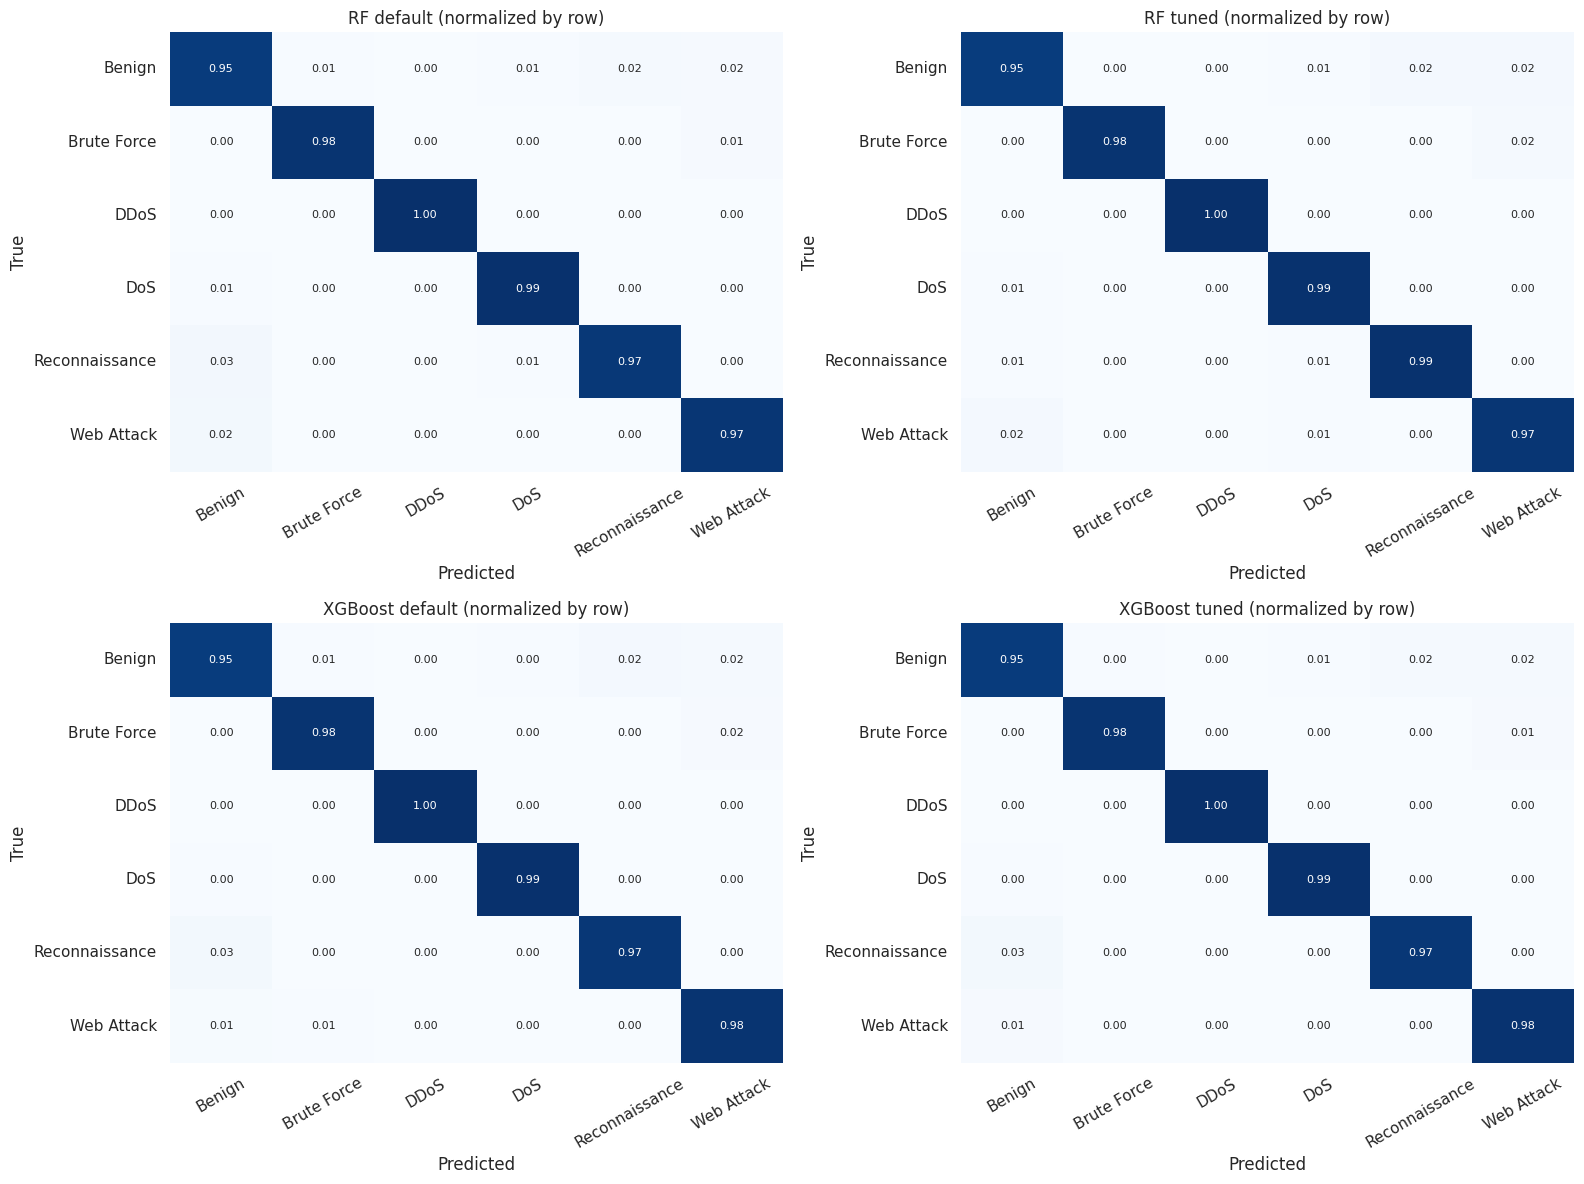

In [11]:
# Confusion matrices (4 modelos)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
panels = [
    ('RF default', y_pred_rf_default),
    ('RF tuned', y_pred_rf_best),
    ('XGBoost default', y_pred_xgb_default),
    ('XGBoost tuned', y_pred_xgb_best),
]
for ax, (name, y_pred) in zip(axes.flat, panels):
    cm = confusion_matrix(y_val_str, le.inverse_transform(y_pred), labels=classes, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar=False,
                annot_kws={'size': 8})
    ax.set_title(f'{name} (normalized by row)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 6. Conclusiones

**Decisión para el notebook 06**: el modelo con mejor F1-macro en val
full pasa al notebook 06.

**Lecturas típicas**:

1. **Tunear ambos cambia el ganador**. XGBoost default suele estar por
   debajo de RF tuned, pero **XGBoost tuned puede igualar o superar al
   RF tuned**, sobre todo en clases minoritarias donde el boosting
   secuencial mejora recall.
2. **Ambos siguen sufriendo en Web Attack y Reconnaissance**. La causa
   raíz no es el modelo sino la **proporción extrema** en val full
   (296K Benign vs 322 Web Attack). Cualquier 1% de FP en Benign son
   3000 falsos positivos que arruinan precision en minorías.
3. **El grid de XGBoost dominó por subsample < 1.0 + max_depth=10 +
   learning_rate bajo + n_estimators alto**, que es el patrón clásico:
   muchos árboles más profundos pero con regularización por subsample.

**Trabajo futuro** (no en este lab):

- SMOTE / ADASYN sobre clases minoritarias antes del fit.
- Calibración de threshold por clase (OvR) post-prediction.
- Stacking RF + XGBoost.

**Próximo notebook (06)**: tomar el ganador, reentrenar sobre train+val
combinados, evaluar en test (no visto hasta acá), persistir como joblibs
con manifest SHA-256 (compatible con `models/manifest.json` del lab).